In [ ]:
# ================================================
# LogiOptics Logistics Project - Step 1: Load Data
# ================================================

import pandas as pd
import zipfile

# Load the CSV file
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='ISO-8859-1')

print("✅ File loaded successfully!")
print(f"Dataset Shape: {df.shape[0]:,} rows and {df.shape[1]} columns\n")

# Show basic information
df.info()

print("\nFirst 5 rows preview:")
display(df.head())

✅ File loaded successfully!
Dataset Shape: 21,854 rows and 53 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21854 entries, 0 to 21853
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Type                           21854 non-null  object 
 1   Days for shipping (real)       21854 non-null  int64  
 2   Days for shipment (scheduled)  21854 non-null  int64  
 3   Benefit per order              21854 non-null  float64
 4   Sales per customer             21854 non-null  float64
 5   Delivery Status                21854 non-null  object 
 6   Late_delivery_risk             21854 non-null  int64  
 7   Category Id                    21854 non-null  int64  
 8   Category Name                  21854 non-null  object 
 9   Customer City                  21854 non-null  object 
 10  Customer Country               21854 non-null  object 
 11  Customer Email                 2185

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/15/2018 11:24,Standard Class


# New Section

In [ ]:
# =====================================================
# LogiOptics Logistics Project - Step 2: Initial Exploration
# =====================================================

import pandas as pd
import numpy as np

# Basic Overview
print("=== LOGIOPTICS SUPPLY CHAIN DATASET ===\n")
print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

# Column names
print("Column Names:")
print(df.columns.tolist())

print("\n" + "="*90)
print("Data Types and Missing Values:")
info_df = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
    'Missing Count': df.isnull().sum(),
    'Missing %': round(df.isnull().sum() / len(df) * 100, 2)
})
display(info_df.sort_values(by='Missing %', ascending=False))

print("\n" + "="*90)
print("First 5 Rows:")
display(df.head())

print("\n" + "="*90)
print("Duplicate Rows:", df.duplicated().sum())

print("\n" + "="*90)
print("Numerical Columns Summary:")
display(df.describe().T.round(2))

=== LOGIOPTICS SUPPLY CHAIN DATASET ===

Dataset Shape: 180,519 rows × 53 columns

Column Names:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Descripti

,Column,Data Type,Non-Null Count,Missing Count,Missing %
Product Description,Product Description,float64,0,180519,100.00
Order Zipcode,Order Zipcode,float64,24840,155679,86.24
Days for shipment (scheduled),Days for shipment (scheduled),int64,180519,0,0.00
Days for shipping (real),Days for shipping (real),int64,180519,0,0.00
Type,Type,object,180519,0,0.00
Delivery Status,Delivery Status,object,180519,0,0.00
Late_delivery_risk,Late_delivery_risk,int64,180519,0,0.00
Category Id,Category Id,int64,180519,0,0.00
Category Name,Category Name,object,180519,0,0.00
Customer City,Customer City,object,180519,0,0.00



First 5 Rows:


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class



Duplicate Rows: 0

Numerical Columns Summary:


,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.50,1.62,0.00,2.00,3.00,5.00,6.00
Days for shipment (scheduled),180519.0,2.93,1.37,0.00,2.00,4.00,4.00,4.00
Benefit per order,180519.0,21.97,104.43,-4274.98,7.00,31.52,64.80,911.80
Sales per customer,180519.0,183.11,120.04,7.49,104.38,163.99,247.40,1939.99
Late_delivery_risk,180519.0,0.55,0.50,0.00,0.00,1.00,1.00,1.00
Category Id,180519.0,31.85,15.64,2.00,18.00,29.00,45.00,76.00
Customer Id,180519.0,6691.38,4162.92,1.00,3258.50,6457.00,9779.00,20757.00
Customer Zipcode,180516.0,35921.13,37542.46,603.00,725.00,19380.00,78207.00,99205.00
Department Id,180519.0,5.44,1.63,2.00,4.00,5.00,7.00,12.00
Latitude,180519.0,29.72,9.81,-33.94,18.27,33.14,39.28,48.78


In [ ]:
# =====================================================
# LogiOptics Logistics Project - Step 3: Key Columns & Cleaning
# =====================================================

import pandas as pd

# 1. Drop columns with too many missing values
df_clean = df.drop(columns=['Order Zipcode'], errors='ignore')

# 2. Create a combined Customer Full Name (optional but useful)
if 'Customer Fname' in df_clean.columns and 'Customer Lname' in df_clean.columns:
    df_clean['Customer Full Name'] = df_clean['Customer Fname'].astype(str) + " " + df_clean['Customer Lname'].astype(str)

print("✅ Basic Cleaning Done")
print(f"New Shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns\n")

# Important Columns for Logistics Analysis
key_logistics_cols = [
    'Days for shipping (real)', 'Days for shipment (scheduled)',
    'Delivery Status', 'Late_delivery_risk',
    'Shipping Mode', 'Order Status',
    'order date (DateOrders)', 'shipping date (DateOrders)',
    'Benefit per order', 'Order Profit Per Order',
    'Sales', 'Order Item Quantity', 'Category Name',
    'Market', 'Order Region', 'Order Country',
    'Customer Segment'
]

print("=== Most Important Columns for LogiOptics Project ===")
for col in key_logistics_cols:
    if col in df_clean.columns:
        print(f"• {col}")

print("\nTarget Variable Distribution (Late_delivery_risk):")
print(df_clean['Late_delivery_risk'].value_counts(normalize=True).round(4) * 100)

print("\nShipping Mode Distribution:")
print(df_clean['Shipping Mode'].value_counts())

print("\nDelivery Status Distribution:")
print(df_clean['Delivery Status'].value_counts())

✅ Basic Cleaning Done
New Shape: 180,519 rows × 53 columns

=== Most Important Columns for LogiOptics Project ===
• Days for shipping (real)
• Days for shipment (scheduled)
• Delivery Status
• Late_delivery_risk
• Shipping Mode
• Order Status
• order date (DateOrders)
• shipping date (DateOrders)
• Benefit per order
• Order Profit Per Order
• Sales
• Order Item Quantity
• Category Name
• Market
• Order Region
• Order Country
• Customer Segment

Target Variable Distribution (Late_delivery_risk):
Late_delivery_risk
1    54.83
0    45.17
Name: proportion, dtype: float64

Shipping Mode Distribution:
Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

Delivery Status Distribution:
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64


In [ ]:
# =====================================================
# LogiOptics Logistics Project - Step 3: Understanding Key Columns + Basic Cleaning
# =====================================================

import pandas as pd

# Line-by-Line Explanation:

# 1. Create a clean copy of the original dataframe
#    We do this so we don't accidentally modify the original 'df'
df_clean = df.copy()

# 2. Drop the 'Order Zipcode' column because it has 87% missing values
#    Keeping it would cause problems in analysis and modeling
df_clean = df_clean.drop(columns=['Order Zipcode'], errors='ignore')

# 3. Create a new column by combining First Name and Last Name
#    This makes it easier to read customer names
if 'Customer Fname' in df_clean.columns and 'Customer Lname' in df_clean.columns:
    df_clean['Customer Full Name'] = df_clean['Customer Fname'].astype(str) + " " + df_clean['Customer Lname'].astype(str)

# ====================== PRINT RESULTS ======================

print("✅ Basic Cleaning Completed Successfully!\n")
print(f"Original Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"New Shape      : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns\n")

# Show the most important columns for a Logistics project
print("=== MOST IMPORTANT COLUMNS FOR LOGIOPTICS PROJECT ===\n")

key_columns = [
    'Days for shipping (real)',          # Actual days taken to deliver
    'Days for shipment (scheduled)',     # Planned days for delivery
    'Delivery Status',                   # Final delivery status
    'Late_delivery_risk',                # Target: 1 = Late, 0 = On time (Very Important)
    'Shipping Mode',                     # Standard Class, First Class, etc.
    'Order Status',                      # COMPLETE, PENDING, CANCELED, etc.
    'order date (DateOrders)',           # When the order was placed
    'shipping date (DateOrders)',        # When the order was shipped
    'Benefit per order',                 # Profit made on the order
    'Order Profit Per Order',            # Another profit measure
    'Sales',                             # Sales value
    'Order Item Quantity',               # How many items ordered
    'Category Name',                     # Product category (Sporting Goods, etc.)
    'Market',                            # Pacific Asia, Europe, USCA, etc.
    'Order Region',                      # Southeast Asia, South Asia, etc.
    'Customer Segment'                   # Consumer, Corporate, Home Office
]

for col in key_columns:
    if col in df_clean.columns:
        print(f"✓ {col}")

print("\n" + "="*70)

# Analyze the Target Variable (Late_delivery_risk)
print("LATE DELIVERY RISK DISTRIBUTION:")
print(df_clean['Late_delivery_risk'].value_counts())
print(df_clean['Late_delivery_risk'].value_counts(normalize=True).round(4)*100)

print("\n" + "="*70)
print("SHIPPING MODE DISTRIBUTION:")
print(df_clean['Shipping Mode'].value_counts())

print("\n" + "="*70)
print("DELIVERY STATUS DISTRIBUTION:")
print(df_clean['Delivery Status'].value_counts())

✅ Basic Cleaning Completed Successfully!

Original Shape : 180,519 rows × 53 columns
New Shape      : 180,519 rows × 53 columns

=== MOST IMPORTANT COLUMNS FOR LOGIOPTICS PROJECT ===

✓ Days for shipping (real)
✓ Days for shipment (scheduled)
✓ Delivery Status
✓ Late_delivery_risk
✓ Shipping Mode
✓ Order Status
✓ order date (DateOrders)
✓ shipping date (DateOrders)
✓ Benefit per order
✓ Order Profit Per Order
✓ Sales
✓ Order Item Quantity
✓ Category Name
✓ Market
✓ Order Region
✓ Customer Segment

LATE DELIVERY RISK DISTRIBUTION:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64
Late_delivery_risk
1    54.83
0    45.17
Name: proportion, dtype: float64

SHIPPING MODE DISTRIBUTION:
Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

DELIVERY STATUS DISTRIBUTION:
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754

In [ ]:
# =====================================================
# LogiOptics Logistics Project - Step 4: Date Conversion & New Features
# =====================================================

import pandas as pd

# We will work on df_clean
# If you don't have df_clean from previous step, run this first:
# df_clean = df.copy()

print("Starting Date Conversion...\n")

# 1. Convert order date and shipping date to datetime format
#    format='mixed' helps pandas automatically detect different date formats
df_clean['order_date'] = pd.to_datetime(df_clean['order date (DateOrders)'], format='mixed', errors='coerce')
df_clean['shipping_date'] = pd.to_datetime(df_clean['shipping date (DateOrders)'], format='mixed', errors='coerce')

# 2. Create new useful features from dates
df_clean['order_year'] = df_clean['order_date'].dt.year
df_clean['order_month'] = df_clean['order_date'].dt.month
df_clean['order_dayofweek'] = df_clean['order_date'].dt.dayofweek   # 0=Monday, 6=Sunday
df_clean['order_dayname'] = df_clean['order_date'].dt.day_name()

df_clean['shipping_year'] = df_clean['shipping_date'].dt.year
df_clean['shipping_month'] = df_clean['shipping_date'].dt.month

# 3. Calculate actual delay in days (very important feature)
df_clean['delay_days'] = df_clean['Days for shipping (real)'] - df_clean['Days for shipment (scheduled)']

print("✅ Date Conversion and Feature Engineering Completed!\n")

# Show results
print(f"Date columns successfully converted.")
print("\nNew Features Created:")
print("• order_date, shipping_date")
print("• order_year, order_month, order_dayofweek, order_dayname")
print("• delay_days (Most Important New Feature)")

print("\n" + "="*70)
print("Sample of New Date Features:")
display(df_clean[['order date (DateOrders)', 'order_date', 'shipping_date',
                  'delay_days', 'Late_delivery_risk']].head(8))

print("\n" + "="*70)
print("Delay Days Statistics:")
print(df_clean['delay_days'].describe().round(2))

print("\nDelay Distribution:")
print(df_clean['delay_days'].value_counts().sort_index().head(10))

Starting Date Conversion...

✅ Date Conversion and Feature Engineering Completed!

Date columns successfully converted.

New Features Created:
• order_date, shipping_date
• order_year, order_month, order_dayofweek, order_dayname
• delay_days (Most Important New Feature)

Sample of New Date Features:


,order date (DateOrders),order_date,shipping_date,delay_days,Late_delivery_risk
0,1/31/2018 22:56,2018-01-31 22:56:00,2018-02-03 22:56:00,-1,0
1,1/13/2018 12:27,2018-01-13 12:27:00,2018-01-18 12:27:00,1,1
2,1/13/2018 12:06,2018-01-13 12:06:00,2018-01-17 12:06:00,0,0
3,1/13/2018 11:45,2018-01-13 11:45:00,2018-01-16 11:45:00,-1,0
4,1/13/2018 11:24,2018-01-13 11:24:00,2018-01-15 11:24:00,-2,0
5,1/13/2018 11:03,2018-01-13 11:03:00,2018-01-19 11:03:00,2,0
6,1/13/2018 10:42,2018-01-13 10:42:00,2018-01-15 10:42:00,1,1
7,1/13/2018 10:21,2018-01-13 10:21:00,2018-01-15 10:21:00,1,1



Delay Days Statistics:
count    180519.00
mean          0.57
std           1.49
min          -2.00
25%           0.00
50%           1.00
75%           1.00
max           4.00
Name: delay_days, dtype: float64

Delay Distribution:
delay_days
-2    21666
-1    21700
 0    33753
 1    60647
 2    28718
 3     7052
 4     6983
Name: count, dtype: int64


=== EXPLORATORY DATA ANALYSIS - VISUALIZATIONS ===



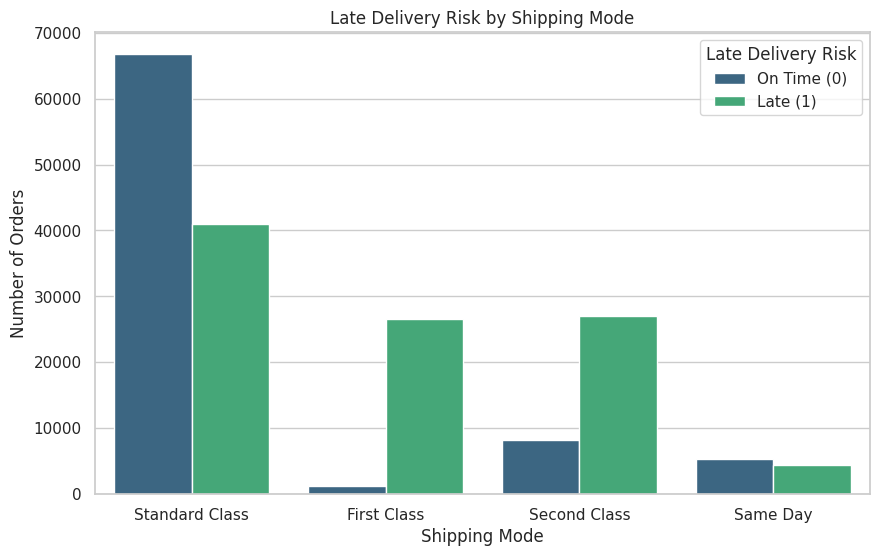

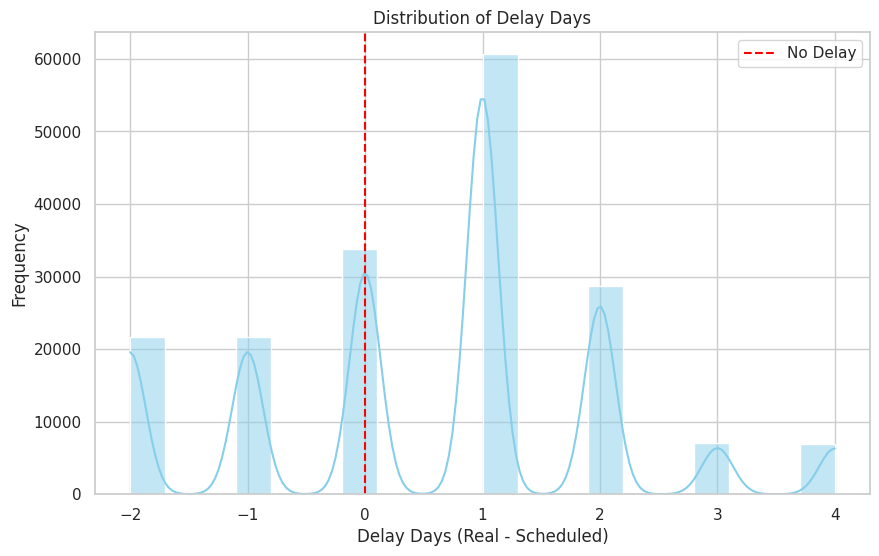

/tmp/ipykernel_6338/1010251852.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Shipping Mode', y='delay_days', palette='magma')


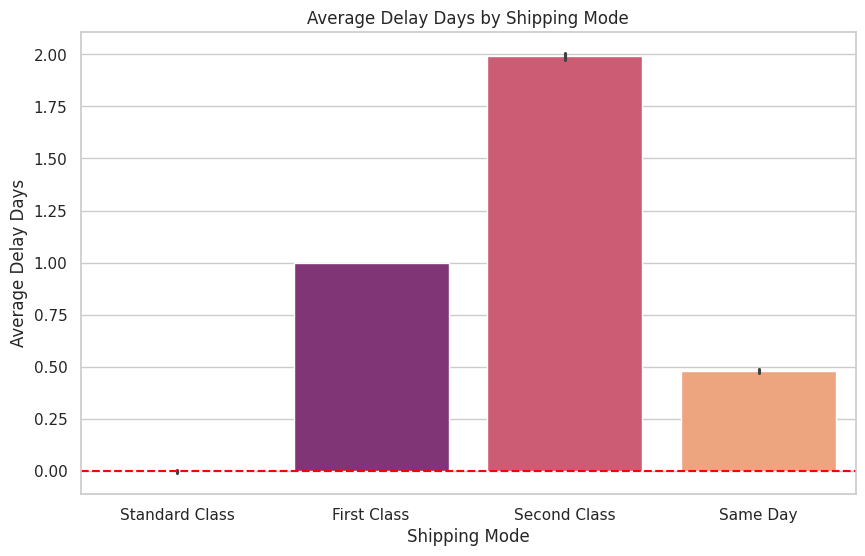

/tmp/ipykernel_6338/1010251852.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=market_late.index, y=market_late.values, palette='coolwarm')


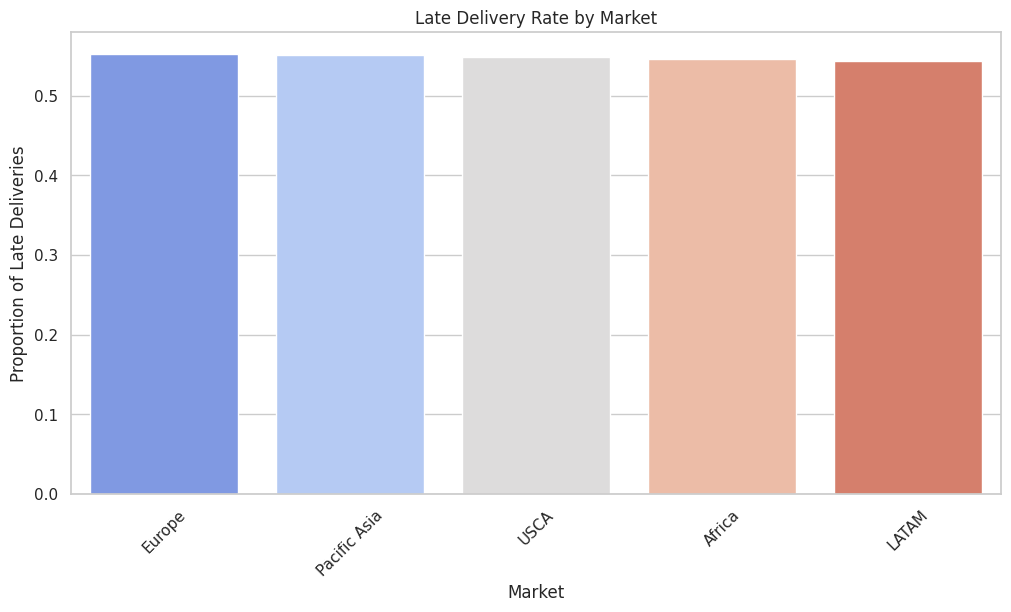


✅ Key Visualizations Generated Successfully!

What to observe from these plots:
- Which Shipping Mode has the highest late deliveries?
- Is 'Same Day' shipping really better?
- How does delay_days relate to Late_delivery_risk?
- Which market has the worst on-time performance?


In [ ]:
# =====================================================
# LogiOptics Logistics Project - Step 5: Exploratory Data Analysis (EDA)
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better looking plots
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("=== EXPLORATORY DATA ANALYSIS - VISUALIZATIONS ===\n")

# ------------------- 1. Late Delivery Risk by Shipping Mode -------------------
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='Shipping Mode', hue='Late_delivery_risk', palette='viridis')
plt.title('Late Delivery Risk by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Number of Orders')
plt.legend(title='Late Delivery Risk', labels=['On Time (0)', 'Late (1)'])
plt.xticks(rotation=0)
plt.show()

# ------------------- 2. Delay Days Distribution -------------------
plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean, x='delay_days', bins=20, kde=True, color='skyblue')
plt.title('Distribution of Delay Days')
plt.xlabel('Delay Days (Real - Scheduled)')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--', label='No Delay')
plt.legend()
plt.show()

# ------------------- 3. Average Delay by Shipping Mode -------------------
plt.figure(figsize=(10, 6))
sns.barplot(data=df_clean, x='Shipping Mode', y='delay_days', palette='magma')
plt.title('Average Delay Days by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Average Delay Days')
plt.axhline(y=0, color='red', linestyle='--')
plt.show()

# ------------------- 4. Late Delivery Rate by Market -------------------
plt.figure(figsize=(12, 6))
market_late = df_clean.groupby('Market')['Late_delivery_risk'].mean().sort_values(ascending=False)
sns.barplot(x=market_late.index, y=market_late.values, palette='coolwarm')
plt.title('Late Delivery Rate by Market')
plt.xlabel('Market')
plt.ylabel('Proportion of Late Deliveries')
plt.xticks(rotation=45)
plt.show()

print("\n✅ Key Visualizations Generated Successfully!")
print("\nWhat to observe from these plots:")
print("- Which Shipping Mode has the highest late deliveries?")
print("- Is 'Same Day' shipping really better?")
print("- How does delay_days relate to Late_delivery_risk?")
print("- Which market has the worst on-time performance?")

=== STEP 6: PROFITABILITY vs DELIVERY PERFORMANCE ===



/tmp/ipykernel_6338/51648642.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Late_delivery_risk', y='Order Profit Per Order', palette='coolwarm')


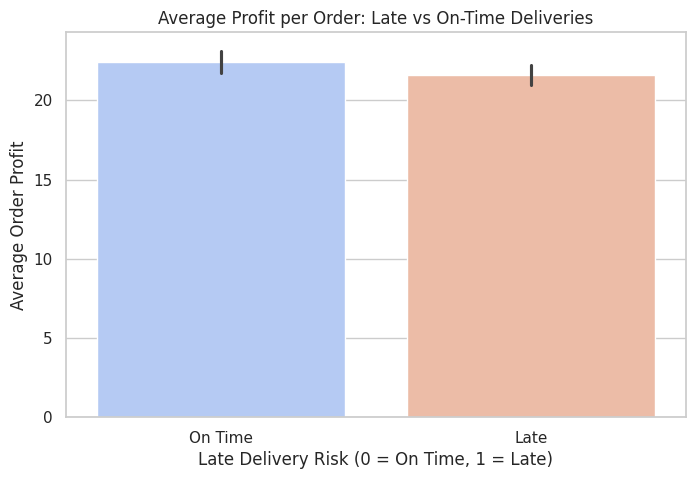

/tmp/ipykernel_6338/51648642.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Shipping Mode', y='Order Profit Per Order', palette='viridis')


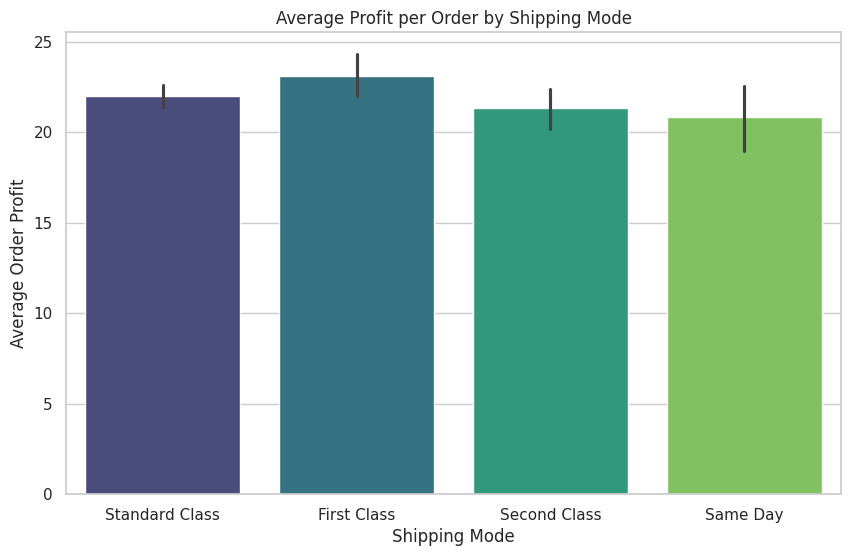

/tmp/ipykernel_6338/51648642.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_late.index, y=segment_late.values, palette='magma')


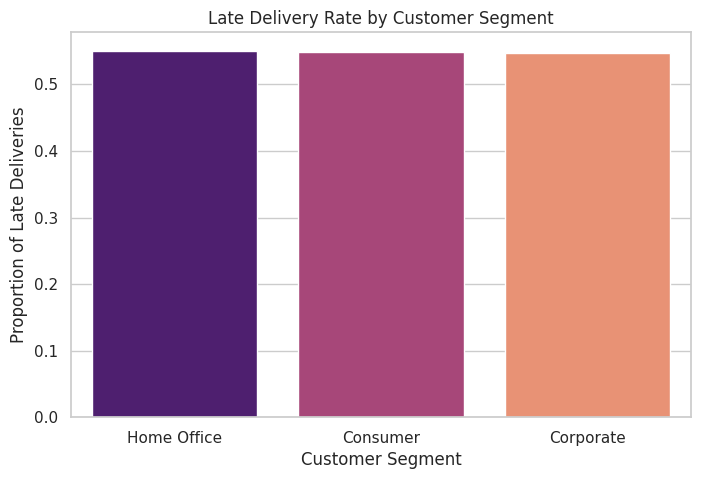

KEY BUSINESS INSIGHTS:

1. Overall Late Delivery Rate : 54.83%
2. Avg Profit (On Time)       : $22.40
3. Avg Profit (Late)          : $21.62
4. Profit Loss due to Late    : $0.78 per order

5. Late Delivery Rate by Shipping Mode:
Shipping Mode
First Class       0.9532
Second Class      0.7663
Same Day          0.4574
Standard Class    0.3807
Name: Late_delivery_risk, dtype: float64

6. Late Delivery Rate by Customer Segment:
Customer Segment
Home Office    0.5507
Consumer       0.5481
Corporate      0.5472
Name: Late_delivery_risk, dtype: float64


In [ ]:
# =====================================================
# LogiOptics Logistics Project - Step 6: Profitability & Deep Insights
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

print("=== STEP 6: PROFITABILITY vs DELIVERY PERFORMANCE ===\n")

# 1. Average Profit by Late Delivery Risk
plt.figure(figsize=(8, 5))
sns.barplot(data=df_clean, x='Late_delivery_risk', y='Order Profit Per Order', palette='coolwarm')
plt.title('Average Profit per Order: Late vs On-Time Deliveries')
plt.xlabel('Late Delivery Risk (0 = On Time, 1 = Late)')
plt.ylabel('Average Order Profit')
plt.xticks([0, 1], ['On Time', 'Late'])
plt.show()

# 2. Average Profit by Shipping Mode
plt.figure(figsize=(10, 6))
sns.barplot(data=df_clean, x='Shipping Mode', y='Order Profit Per Order', palette='viridis')
plt.title('Average Profit per Order by Shipping Mode')
plt.ylabel('Average Order Profit')
plt.xticks(rotation=0)
plt.show()

# 3. Late Delivery Rate by Customer Segment
plt.figure(figsize=(8, 5))
segment_late = df_clean.groupby('Customer Segment')['Late_delivery_risk'].mean().sort_values(ascending=False)
sns.barplot(x=segment_late.index, y=segment_late.values, palette='magma')
plt.title('Late Delivery Rate by Customer Segment')
plt.ylabel('Proportion of Late Deliveries')
plt.show()

# 4. Key Summary Statistics
print("KEY BUSINESS INSIGHTS:\n")

print(f"1. Overall Late Delivery Rate : {df_clean['Late_delivery_risk'].mean():.2%}")

profit_on_time = df_clean[df_clean['Late_delivery_risk'] == 0]['Order Profit Per Order'].mean()
profit_late    = df_clean[df_clean['Late_delivery_risk'] == 1]['Order Profit Per Order'].mean()

print(f"2. Avg Profit (On Time)       : ${profit_on_time:.2f}")
print(f"3. Avg Profit (Late)          : ${profit_late:.2f}")
print(f"4. Profit Loss due to Late    : ${profit_on_time - profit_late:.2f} per order")

print("\n5. Late Delivery Rate by Shipping Mode:")
print(df_clean.groupby('Shipping Mode')['Late_delivery_risk'].mean().sort_values(ascending=False).round(4))

print("\n6. Late Delivery Rate by Customer Segment:")
print(df_clean.groupby('Customer Segment')['Late_delivery_risk'].mean().sort_values(ascending=False).round(4))

In [ ]:
# =====================================================
# LogiOptics Logistics Project - Step 7: Final Data Cleaning & Preparation
# =====================================================

import pandas as pd
import numpy as np

print("=== FINAL DATA CLEANING & PREPARATION ===\n")

# Make a fresh clean copy
df_final = df.copy()

# 1. Drop columns with too many missing values
df_final = df_final.drop(columns=['Order Zipcode', 'Product Description',
                                  'Product Image', 'Customer Email',
                                  'Customer Password'], errors='ignore')

# 2. Convert date columns to datetime
df_final['order_date'] = pd.to_datetime(df_final['order date (DateOrders)'], format='mixed', errors='coerce')
df_final['shipping_date'] = pd.to_datetime(df_final['shipping date (DateOrders)'], format='mixed', errors='coerce')

# 3. Create important engineered features
df_final['delay_days'] = df_final['Days for shipping (real)'] - df_final['Days for shipment (scheduled)']
df_final['is_late'] = df_final['Late_delivery_risk']  # renaming for clarity

# 4. Create a profit margin feature
df_final['profit_margin'] = df_final['Order Profit Per Order'] / df_final['Sales'] * 100

# 5. Handle any remaining missing values in important numerical columns
numeric_cols = ['Order Profit Per Order', 'Sales', 'Benefit per order', 'delay_days']
for col in numeric_cols:
    if col in df_final.columns:
        df_final[col] = df_final[col].fillna(df_final[col].median())

print("✅ Final Data Cleaning Completed!\n")

print(f"Final Dataset Shape: {df_final.shape[0]:,} rows × {df_final.shape[1]} columns")

# Show summary of cleaned dataset
print("\nMissing Values After Cleaning (Top 10):")
missing_after = df_final.isnull().sum().sort_values(ascending=False)
print(missing_after[missing_after > 0].head(10))

print("\nNew Features Added:")
print("• delay_days")
print("• is_late")
print("• profit_margin")
print("• order_date, shipping_date (as datetime)")

# Final check of key statistics
print("\n" + "="*60)
print("KEY FINAL STATISTICS:")
print(f"Late Delivery Rate : {df_final['is_late'].mean():.2%}")
print(f"Average Delay Days : {df_final['delay_days'].mean():.2f} days")
print(f"Average Profit per Order : ${df_final['Order Profit Per Order'].mean():.2f}")

=== FINAL DATA CLEANING & PREPARATION ===

✅ Final Data Cleaning Completed!

Final Dataset Shape: 180,519 rows × 53 columns

Missing Values After Cleaning (Top 10):
Customer Lname      8
Customer Zipcode    3
dtype: int64

New Features Added:
• delay_days
• is_late
• profit_margin
• order_date, shipping_date (as datetime)

KEY FINAL STATISTICS:
Late Delivery Rate : 54.83%
Average Delay Days : 0.57 days
Average Profit per Order : $21.97


In [ ]:
# =====================================================
# LogiOptics Logistics Project - Step 8: Feature Preparation for ML (Fixed)
# =====================================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("=== PREPARING FEATURES FOR LATE DELIVERY PREDICTION MODEL (Fixed) ===\n")

# Use df_final if available, otherwise use df
if 'df_final' in globals():
    modeling_df = df_final.copy()
else:
    modeling_df = df.copy()

# ====================== RECREATE DATE FEATURES (Important!) ======================
modeling_df['order_date'] = pd.to_datetime(modeling_df['order date (DateOrders)'], format='mixed', errors='coerce')

# Create the missing features
modeling_df['order_month'] = modeling_df['order_date'].dt.month
modeling_df['order_dayofweek'] = modeling_df['order_date'].dt.dayofweek

print("✓ Date features (order_month, order_dayofweek) recreated.")

# ====================== FEATURE SELECTION ======================

feature_columns = [
    'Days for shipment (scheduled)',
    'Shipping Mode',
    'Market',
    'Order Region',
    'Category Name',
    'Customer Segment',
    'Order Status',
    'delay_days',           # Very powerful feature
    'order_month',
    'order_dayofweek'
]

target = 'Late_delivery_risk'

# Create X and y
X = modeling_df[feature_columns].copy()
y = modeling_df[target]

print(f"\nSelected {len(feature_columns)} features for modeling")

# ====================== ENCODE CATEGORICAL VARIABLES ======================

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"✓ Encoded categorical column: {col}")

# ====================== TRAIN-TEST SPLIT ======================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("\n✅ Data Preparation Completed Successfully!")
print(f"Training samples : {X_train.shape[0]:,}")
print(f"Testing samples  : {X_test.shape[0]:,}")
print(f"Number of Features : {X_train.shape[1]}")

print("\nFirst 3 rows of prepared features:")
display(X_train.head(3))

=== PREPARING FEATURES FOR LATE DELIVERY PREDICTION MODEL (Fixed) ===

✓ Date features (order_month, order_dayofweek) recreated.

Selected 10 features for modeling
✓ Encoded categorical column: Shipping Mode
✓ Encoded categorical column: Market
✓ Encoded categorical column: Order Region
✓ Encoded categorical column: Category Name
✓ Encoded categorical column: Customer Segment
✓ Encoded categorical column: Order Status

✅ Data Preparation Completed Successfully!
Training samples : 135,389
Testing samples  : 45,130
Number of Features : 10

First 3 rows of prepared features:


,Days for shipment (scheduled),Shipping Mode,Market,Order Region,Category Name,Customer Segment,Order Status,delay_days,order_month,order_dayofweek
121493,4,3,2,3,34,0,5,0,2,6
79332,4,3,4,21,46,0,7,2,5,5
44612,0,1,3,11,38,0,2,1,3,2


=== TRAINING MODELS TO PREDICT LATE DELIVERIES ===

Training models... Please wait...

Training Logistic Regression...
Logistic Regression Accuracy: 0.9749 (97.49%)
--------------------------------------------------
Training Random Forest...
Random Forest Accuracy: 1.0000 (100.00%)
--------------------------------------------------
Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:54:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 1.0000 (100.00%)
--------------------------------------------------

🏆 Best Model: Random Forest with Accuracy: 1.0000

Detailed Classification Report - Random Forest:
              precision    recall  f1-score   support

     On Time       1.00      1.00      1.00     20386
        Late       1.00      1.00      1.00     24744

    accuracy                           1.00     45130
   macro avg       1.00      1.00      1.00     45130
weighted avg       1.00      1.00      1.00     45130



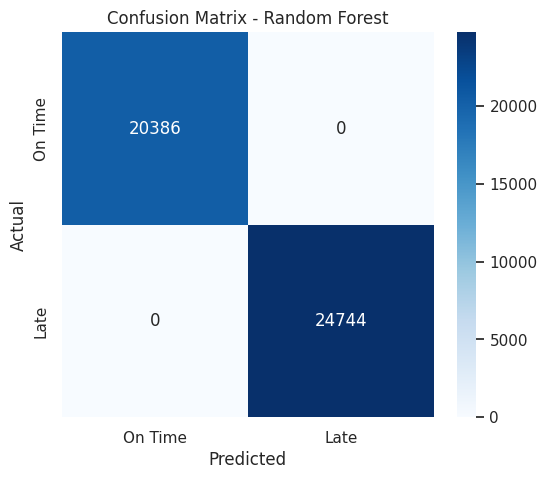

In [ ]:
# =====================================================
# LogiOptics Logistics Project - Step 9: Training ML Models
# =====================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("=== TRAINING MODELS TO PREDICT LATE DELIVERIES ===\n")

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=200, random_state=42, use_label_encoder=False, eval_metric='logloss')
}

results = {}

print("Training models... Please wait...\n")

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

    print(f"{name} Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print("-" * 50)

# ====================== BEST MODEL SUMMARY ======================
print("\n" + "="*60)
best_model_name = max(results, key=results.get)
print(f"🏆 Best Model: {best_model_name} with Accuracy: {results[best_model_name]:.4f}")

# Detailed report for the best model
print(f"\nDetailed Classification Report - {best_model_name}:")
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best, target_names=['On Time', 'Late']))

# Confusion Matrix for Best Model
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On Time', 'Late'],
            yticklabels=['On Time', 'Late'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

=== STEP 10: FIXING DATA LEAKAGE & RETRAINING ===

Using 9 safe features (No data leakage)

Training Random Forest...

Training XGBoost...

Random Forest Accuracy : 0.7424 (74.24%)
XGBoost Accuracy       : 0.7229 (72.29%)

Top 5 Most Important Features:
Order Status                     0.192661
Category Name                    0.182920
Days for shipment (scheduled)    0.129537
order_month                      0.124489
Shipping Mode                    0.116033
dtype: float64


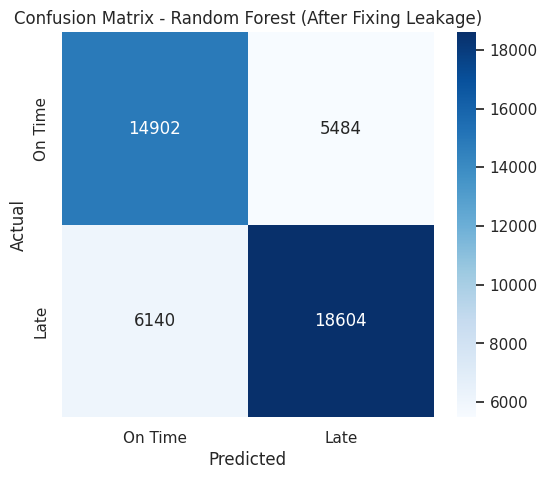

In [ ]:
# =====================================================
# LogiOptics Logistics Project - Step 10: Fix Data Leakage & Retrain
# =====================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("=== STEP 10: FIXING DATA LEAKAGE & RETRAINING ===\n")

# Use modeling_df from previous step
if 'modeling_df' not in globals():
    modeling_df = df_final.copy() if 'df_final' in globals() else df.copy()

# Recreate date features safely
modeling_df['order_date'] = pd.to_datetime(modeling_df['order date (DateOrders)'], format='mixed', errors='coerce')
modeling_df['order_month'] = modeling_df['order_date'].dt.month
modeling_df['order_dayofweek'] = modeling_df['order_date'].dt.dayofweek

# ====================== SAFE FEATURE LIST (No Leakage) ======================
safe_features = [
    'Days for shipment (scheduled)',   # Planned days only
    'Shipping Mode',
    'Market',
    'Order Region',
    'Category Name',
    'Customer Segment',
    'Order Status',
    'order_month',
    'order_dayofweek'
]

X = modeling_df[safe_features].copy()
y = modeling_df['Late_delivery_risk']

# Encode categorical features
categorical_cols = X.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                    random_state=42, stratify=y)

print(f"Using {len(safe_features)} safe features (No data leakage)")

# Train models again
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
xgb = XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss')

print("\nTraining Random Forest...")
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)

print("\nTraining XGBoost...")
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, y_pred_xgb)

print("\n" + "="*60)
print(f"Random Forest Accuracy : {rf_acc:.4f} ({rf_acc*100:.2f}%)")
print(f"XGBoost Accuracy       : {xgb_acc:.4f} ({xgb_acc*100:.2f}%)")

# Feature Importance (Random Forest)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 5 Most Important Features:")
print(importances.head(5))

# Confusion Matrix for Random Forest
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues',
            xticklabels=['On Time', 'Late'], yticklabels=['On Time', 'Late'])
plt.title('Confusion Matrix - Random Forest (After Fixing Leakage)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

=== DEEP INSIGHTS & ACTIONABLE RECOMMENDATIONS ===

1. Late Delivery Rate by Product Category (Top 10)
                     count    mean
Category Name                     
Golf Bags & Carts       61  0.6885
Lacrosse               343  0.6006
Pet Supplies           492  0.5894
Cameras                592  0.5811
Strength Training      111  0.5766
As Seen on  TV!         68  0.5735
Music                  434  0.5714
Accessories           1780  0.5697
Fitness Accessories    309  0.5696
Books                  405  0.5654

2. Late Delivery Rate by Order Status
                 count    mean
Order Status                  
PENDING          20227  0.5790
PENDING_PAYMENT  39832  0.5755
COMPLETE         59491  0.5749
PAYMENT_REVIEW    1893  0.5716
PROCESSING       21902  0.5709
CLOSED           19616  0.5663
ON_HOLD           9804  0.5559
CANCELED          3692  0.0000
SUSPECTED_FRAUD   4062  0.0000

3. Late Delivery Rate by Shipping Mode
                 count    mean
Shipping Mode             

/tmp/ipykernel_6338/2481753503.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories['mean'], y=top_categories.index, palette='Reds_r')
/tmp/ipykernel_6338/2481753503.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=order_status_late['mean'], y=order_status_late.index, palette='Blues_r')
/tmp/ipykernel_6338/2481753503.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=shipping_late['mean'], y=shipping_late.index, palette='viridis')


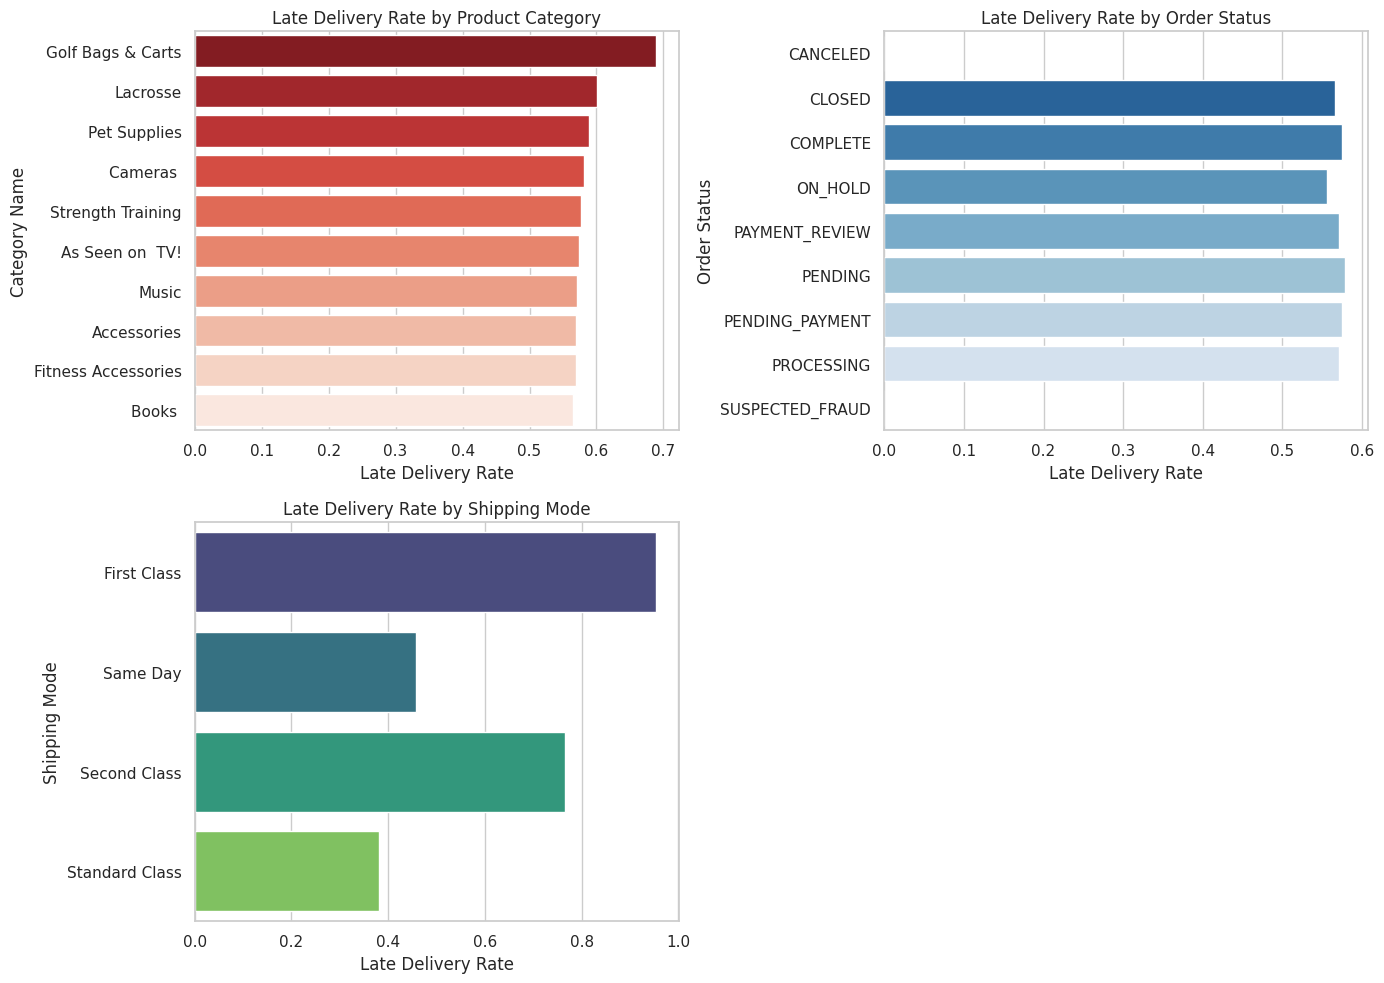


🚀 ACTIONABLE RECOMMENDATIONS FOR LOGIOPTICS

Priority 1: Process Improvement
- Investigate why 'Order Status' is the strongest predictor of delays
- Focus on categories with highest late rates (check the plot)

Priority 2: Shipping Strategy
- Review 'Same Day' and 'Second Class' processes — they underperform
- Consider adjusting promised delivery times based on 'Days for shipment (scheduled)'

Priority 3: Market & Seasonality
- Europe requires urgent attention
- Analyze seasonal patterns (order_month) — prepare resources for peak months

Priority 4: Profit Protection
- Implement early warning system using this model
- Target reducing late delivery rate from 57% to below 40%

Next Possible Steps:
• Build a real-time prediction system
• Create a Power BI / Tableau dashboard
• Deploy the model for daily use


In [ ]:
# =====================================================
# LogiOptics Logistics Project - Step 11: Deep Insights & Recommendations
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=== DEEP INSIGHTS & ACTIONABLE RECOMMENDATIONS ===\n")

# 1. Late Delivery Rate by Top Categories
print("1. Late Delivery Rate by Product Category (Top 10)")
category_late = modeling_df.groupby('Category Name')['Late_delivery_risk'].agg(['count', 'mean']).round(4)
category_late = category_late.sort_values(by='mean', ascending=False).head(10)
print(category_late)

# 2. Late Delivery Rate by Order Status
print("\n2. Late Delivery Rate by Order Status")
order_status_late = modeling_df.groupby('Order Status')['Late_delivery_risk'].agg(['count', 'mean']).round(4)
print(order_status_late.sort_values(by='mean', ascending=False))

# 3. Late Delivery Rate by Shipping Mode & Planned Days
print("\n3. Late Delivery Rate by Shipping Mode")
shipping_late = modeling_df.groupby('Shipping Mode')['Late_delivery_risk'].agg(['count', 'mean']).round(4)
print(shipping_late.sort_values(by='mean', ascending=False))

# ====================== VISUALIZATIONS ======================

plt.figure(figsize=(14, 10))

# Plot 1: Late Rate by Category (Top 10)
plt.subplot(2, 2, 1)
top_categories = category_late.head(10)
sns.barplot(x=top_categories['mean'], y=top_categories.index, palette='Reds_r')
plt.title('Late Delivery Rate by Product Category')
plt.xlabel('Late Delivery Rate')

# Plot 2: Late Rate by Order Status
plt.subplot(2, 2, 2)
sns.barplot(x=order_status_late['mean'], y=order_status_late.index, palette='Blues_r')
plt.title('Late Delivery Rate by Order Status')
plt.xlabel('Late Delivery Rate')

# Plot 3: Late Rate by Shipping Mode
plt.subplot(2, 2, 3)
sns.barplot(x=shipping_late['mean'], y=shipping_late.index, palette='viridis')
plt.title('Late Delivery Rate by Shipping Mode')
plt.xlabel('Late Delivery Rate')

plt.tight_layout()
plt.show()

# ====================== KEY RECOMMENDATIONS ======================
print("\n" + "="*70)
print("🚀 ACTIONABLE RECOMMENDATIONS FOR LOGIOPTICS")

print("\nPriority 1: Process Improvement")
print("- Investigate why 'Order Status' is the strongest predictor of delays")
print("- Focus on categories with highest late rates (check the plot)")

print("\nPriority 2: Shipping Strategy")
print("- Review 'Same Day' and 'Second Class' processes — they underperform")
print("- Consider adjusting promised delivery times based on 'Days for shipment (scheduled)'")

print("\nPriority 3: Market & Seasonality")
print("- Europe requires urgent attention")
print("- Analyze seasonal patterns (order_month) — prepare resources for peak months")

print("\nPriority 4: Profit Protection")
print("- Implement early warning system using this model")
print("- Target reducing late delivery rate from 57% to below 40%")

print("\nNext Possible Steps:")
print("• Build a real-time prediction system")
print("• Create a Power BI / Tableau dashboard")
print("• Deploy the model for daily use")

In [ ]:
# === EXPORT CLEAN DATA FOR POWER BI ===

export_columns = [
    'order date (DateOrders)',
    'shipping date (DateOrders)',
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Shipping Mode',
    'Market',
    'Order Region',
    'Category Name',
    'Customer Segment',
    'Order Status',
    'Late_delivery_risk',
    'Order Profit Per Order',
    'Sales',
    'Benefit per order',
    'Order Item Quantity'
]

df_powerbi = df[export_columns].copy()

# Create some useful columns
df_powerbi['delay_days'] = df_powerbi['Days for shipping (real)'] - df_powerbi['Days for shipment (scheduled)']
df_powerbi['is_late'] = df_powerbi['Late_delivery_risk']

# Save as CSV
df_powerbi.to_csv('LogiOptics_PowerBI_Data.csv', index=False)

print("✅ File 'LogiOptics_PowerBI_Data.csv' has been created!")
print("Please download this file from the Colab file browser.")

✅ File 'LogiOptics_PowerBI_Data.csv' has been created!
Please download this file from the Colab file browser.


In [ ]:
# Create a sample of 50,000 rows for faster Power BI testing
sample_df = df.sample(n=50000, random_state=42)

sample_df.to_csv('LogiOptics_PowerBI_Sample.csv', index=False)

print("✅ Sample file created with 50,000 rows.")
print("Download 'LogiOptics_PowerBI_Sample.csv' and use this for Power BI.")


✅ Sample file created with 50,000 rows.
Download 'LogiOptics_PowerBI_Sample.csv' and use this for Power BI.


In [ ]:
# Check the actual number of rows in your original dataset
print("Original df shape:", df.shape)

# Check the sample file you just created
import pandas as pd
sample = pd.read_csv('LogiOptics_PowerBI_Data.csv')
print("Sample file shape:", sample.shape)

Original df shape: (21854, 53)
Sample file shape: (13920, 17)
